# Lab 02：word2vec——從「猜鄰居」長出詞向量

對應講義：[第 02 課](../lessons/02_word2vec.md)

1. 在一個「結構已知」的玩具語料上訓練 skip-gram ＋ negative sampling（式 2.3），看類比（式 2.6）與向量的方向
2. 拿掉區分 son／boy 的上下文，看類比怎麼壞掉（§2.5）
3. 視窗大小會改變學到的關係
4. 計數派：shifted PPMI ＋ SVD（式 2.9），以及 SGNS 的內積和 PMI 的關係（式 2.8）
5. 換成真實文字（TinyStories）：鄰居、類比、反義詞

CPU 約 1 分鐘。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from lm_course.utils import notebook_logging, set_seed

%matplotlib inline
plt.rcParams["figure.dpi"] = 80
notebook_logging()
set_seed(0)
print(f"torch {torch.__version__}")

torch 2.14.0+cu130


## 1. 玩具世界

`toy_world_corpus` 用模板造句：10 對男女人物（king／queen、boy／girl…）與 12 個國家（首都、語言）。
性別只藏在旁邊的 he／she／his／her 裡，王室只藏在 palace／crown 裡，首都只藏在 city 類的詞與該國語言裡——我們**知道**正確答案，所以能檢查 word2vec 學到了什麼。

In [2]:
from lm_course.data import toy_world_analogies, toy_world_corpus
from lm_course.word2vec import build_vocab, encode_sentences

corpus = toy_world_corpus(100_000, seed=0)
vocab = build_vocab(corpus, min_count=1)
ids = encode_sentences(corpus, vocab)
analogies = toy_world_analogies()
print(f"{len(corpus):,} sentences, {sum(len(s) for s in corpus):,} words, vocabulary {len(vocab)}")
for sentence in corpus[:6]:
    print("  ", " ".join(sentence))
print(f"{len(analogies)} analogies, e.g. {analogies[0]} and {analogies[-1]}")

100,000 sentences, 707,065 words, vocabulary 164
   the city of beijing is famous
   greek is the language of greece
   greece is a neighbor of russia
   people in berlin speak german
   the prince lives in his palace
   people in ankara speak turkish
177 analogies, e.g. Analogy(a='king', b='queen', c='prince', d='princess', relation='gender') and Analogy(a='sweden', b='swedish', c='turkey', d='turkish', relation='language')


In [3]:
from lm_course.word2vec import analogy_accuracy, most_similar, train_skipgram

result = train_skipgram(ids, vocab, dim=50, window=5, negatives=5, epochs=3, subsample_t=1e-3, log_every=0)
emb = result.model.embeddings()
print(f"{result.num_pairs:,} training pairs in {result.seconds:.0f}s")
print("analogy accuracy:", {k: round(v, 3) for k, v in analogy_accuracy(emb, vocab, analogies).items()})
for word in ["king", "paris", "french", "she"]:
    print(f"{word:>7} ->", ", ".join(f"{w} {s:.2f}" for w, s in most_similar(emb, vocab, word, 5)))

1,493,402 training pairs in 10s
analogy accuracy: {'gender': 1.0, 'all': 0.997, 'capital': 1.0, 'language': 0.992}
   king -> queen 0.87, prince 0.81, princess 0.69, brother 0.68, husband 0.67
  paris -> ankara 0.79, berlin 0.79, stockholm 0.79, moscow 0.78, athens 0.78
 french -> turkish 0.70, swedish 0.68, polish 0.67, portuguese 0.67, spanish 0.65
    she -> before 0.54, moving 0.54, learned 0.52, at 0.44, today 0.44


幾乎所有類比都答對。注意降採樣門檻用的是 $t = 10^{-3}$，不是論文建議的 $10^{-5}$：玩具語料只有一百多個詞，每個詞的頻率都很高，$10^{-5}$ 會把幾乎所有詞都丟掉。

**向量的方向**：同一種關係的位移（queen − king、woman − man…）應該差不多平行。畫圖時 x 軸取這種關係的**平均位移方向**，y 軸取扣掉它之後變化最大的方向（PCA）：如果位移真的平行，箭頭會全部指向右邊、長度相近。

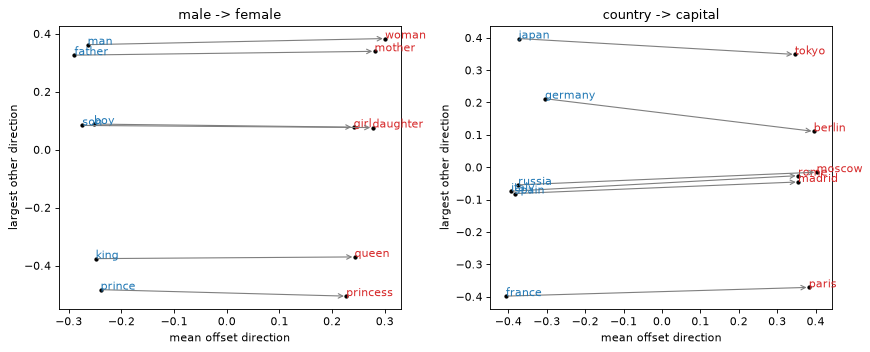

In [4]:
from lm_course.data import COUNTRIES, GENDER_PAIRS
from lm_course.word2vec import normalize_rows


# x: the mean offset from each even row to the next odd row; y: the top PCA direction of the rest
def relation_plane(vectors: np.ndarray) -> np.ndarray:
    offset = (vectors[1::2] - vectors[0::2]).mean(axis=0)
    offset /= np.linalg.norm(offset)
    centered = vectors - vectors.mean(axis=0)
    x = centered @ offset
    rest = centered - np.outer(x, offset)
    _, _, vt = np.linalg.svd(rest, full_matrices=False)
    return np.stack([x, rest @ vt[0]], axis=1)


unit = normalize_rows(emb)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, pairs, title in [
    (axes[0], GENDER_PAIRS[:6], "male -> female"),
    (axes[1], [(country, capital) for country, capital, _ in COUNTRIES[:6]], "country -> capital"),
]:
    words = [w for pair in pairs for w in pair]
    xy = relation_plane(unit[[vocab.index[w] for w in words]])
    for i, (a, b) in enumerate(pairs):
        pa, pb = xy[2 * i], xy[2 * i + 1]
        ax.annotate("", xy=pb, xytext=pa, arrowprops=dict(arrowstyle="->", color="tab:gray"))
        ax.text(*pa, a, color="tab:blue")
        ax.text(*pb, b, color="tab:red")
    ax.scatter(xy[:, 0], xy[:, 1], s=8, color="k")
    ax.set_title(title)
    ax.set_xlabel("mean offset direction")
    ax.set_ylabel("largest other direction")
plt.tight_layout()
plt.show()

## 2. 語料沒說的，模型就不知道

玩具世界預設替每一對人物加了一個專屬的上下文（king 統治王國、son 照顧年邁的父母、boy 玩玩具車…）。
拿掉它（`with_roles=False`），son 和 boy、brother 和 uncle 的上下文就一模一樣了。

In [5]:
from lm_course.word2vec import solve_analogy

plain = toy_world_corpus(100_000, seed=0, with_roles=False)
plain_vocab = build_vocab(plain, min_count=1)
plain_result = train_skipgram(
    encode_sentences(plain, plain_vocab), plain_vocab, dim=50, window=5, epochs=3, subsample_t=1e-3, log_every=0
)
plain_emb = plain_result.model.embeddings()
print("accuracy without roles:", {k: round(v, 3) for k, v in analogy_accuracy(plain_emb, plain_vocab, analogies).items()})
wrong = [
    (q.a, q.b, q.c, q.d, solve_analogy(plain_emb, plain_vocab, q.a, q.b, q.c))
    for q in analogies
    if q.relation == "gender"
]
wrong = [w for w in wrong if w[3] != w[4]]
for a, b, c, d, got in wrong[:8]:
    print(f"  {a} : {b} :: {c} : ?   expected {d}, got {got}")

accuracy without roles: {'gender': 0.411, 'all': 0.847, 'capital': 1.0, 'language': 0.992}
  king : queen :: boy : ?   expected girl, got niece
  king : queen :: father : ?   expected mother, got wife
  king : queen :: son : ?   expected daughter, got niece
  king : queen :: brother : ?   expected sister, got woman
  king : queen :: uncle : ?   expected aunt, got woman
  king : queen :: husband : ?   expected wife, got woman
  king : queen :: nephew : ?   expected niece, got girl
  prince : princess :: man : ?   expected woman, got sister


錯的答案都「性別正確、角色錯」：king : queen :: son : ? 答 niece 而不是 daughter。在這個語料裡，son、boy、nephew 出現在完全相同的句子裡，**它們的向量本來就該一樣**——模型沒有錯，是語料沒提供區分它們的訊息（講義 §2.5）。國家的類比完全不受影響。

## 3. 視窗大小

「she learned **french** before moving to **france**」：語言和國家之間隔了 3 個詞。視窗太小，這種關係就學不到。

In [6]:
for window in (1, 2, 5):
    r = train_skipgram(ids, vocab, dim=50, window=window, epochs=3, subsample_t=1e-3, log_every=0)
    acc = analogy_accuracy(r.model.embeddings(), vocab, analogies)
    print(f"window {window}: " + ", ".join(f"{k} {v:.2f}" for k, v in acc.items()))

window 1: gender 1.00, all 0.86, capital 1.00, language 0.62


window 2: gender 1.00, all 0.98, capital 1.00, language 0.95


window 5: gender 1.00, all 1.00, capital 1.00, language 0.99


## 4. 計數派：shifted PPMI ＋ SVD

講義式 (2.8)：SGNS 的最佳解是 $v_w^\top u_c = \mathrm{PMI}(w,c) - \log K$。
那就直接算：共現矩陣 → PMI → 減 $\log K$、負的截成 0 → SVD 取前 50 維（式 2.9）。

In [7]:
from lm_course.word2vec import cooccurrence_matrix, pmi_matrix, shifted_ppmi, svd_embeddings

cooc = cooccurrence_matrix(ids, len(vocab), window=5)
for k in (1, 5):
    for power in (1.0, 0.75):
        svd_emb = svd_embeddings(shifted_ppmi(cooc, k=k, context_power=power), 50)
        acc = analogy_accuracy(svd_emb, vocab, analogies)
        print(f"PPMI-SVD  k={k}  context power {power}: " + ", ".join(f"{r} {v:.2f}" for r, v in acc.items()))

PPMI-SVD  k=1  context power 1.0: gender 1.00, all 1.00, capital 1.00, language 1.00
PPMI-SVD  k=1  context power 0.75: gender 1.00, all 1.00, capital 1.00, language 1.00
PPMI-SVD  k=5  context power 1.0: gender 1.00, all 0.65, capital 0.54, language 0.52
PPMI-SVD  k=5  context power 0.75: gender 1.00, all 0.38, capital 0.25, language 0.10


$k = 1$ 時計數派全部答對，和 SGNS 一樣好；$k = 5$ 時首都與語言的類比就掉很多，取 0.75 次方反而更糟。結果對 $k$ 與「上下文分布要不要取 0.75 次方」很敏感——這正是 Levy、Goldberg、Dagan（2015）的觀察：兩派的差距很多來自這類超參數，而不是「預測 vs 計數」本身。

**SGNS 的內積 vs. PMI**：拿 §1 訓練好的 SGNS，比較每一格的 $v_w^\top u_c$ 與 $\mathrm{PMI}(w,c) - \log 5$（雜訊分布是 unigram 的 0.75 次方，所以 PMI 的上下文分布也取 0.75 次方）。
維度 50 小於詞彙量，而且訓練用的是降採樣過的資料，所以不會完全相等，但趨勢應該很明顯。

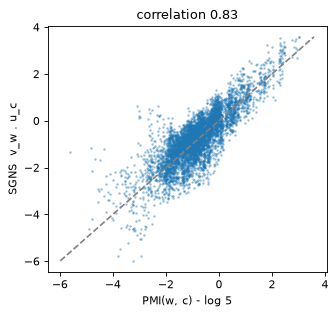

In [8]:
center = result.model.center.weight.detach().numpy()
context = result.model.context.weight.detach().numpy()
dots = center @ context.T
pmi = pmi_matrix(cooc, context_power=0.75) - np.log(5)
seen = cooc >= 20  # cells with enough counts for a stable PMI
corr = np.corrcoef(dots[seen], pmi[seen])[0, 1]
plt.figure(figsize=(4.5, 4))
plt.scatter(pmi[seen], dots[seen], s=2, alpha=0.3)
lims = [min(pmi[seen].min(), dots[seen].min()), max(pmi[seen].max(), dots[seen].max())]
plt.plot(lims, lims, "--", color="gray")
plt.xlabel("PMI(w, c) - log 5")
plt.ylabel("SGNS  v_w . u_c")
plt.title(f"correlation {corr:.2f}")
plt.show()

## 5. 真實文字：TinyStories

把全部訓練故事切成小寫單字，出現少於 10 次的詞丟掉，訓練一個 64 維的 SGNS。

In [9]:
from lm_course.artifacts import course_stories
from lm_course.word2vec import words_from_text

train_stories, _ = course_stories()
sentences = [words_from_text(story) for story in train_stories]
ts_vocab = build_vocab(sentences, min_count=10)
ts_ids = encode_sentences(sentences, ts_vocab)
ts = train_skipgram(ts_ids, ts_vocab, dim=64, window=4, epochs=1, batch_size=8192, subsample_t=1e-4, log_every=0)
ts_emb = ts.model.embeddings()
print(f"vocabulary {len(ts_vocab):,}, {sum(len(s) for s in ts_ids):,} words, {ts.num_pairs:,} pairs, {ts.seconds:.0f}s")
for word in ["dog", "happy", "red", "ran", "apple", "king", "three", "mom"]:
    print(f"{word:>6} ->", ", ".join(w for w, _ in most_similar(ts_emb, ts_vocab, word, 6)))

vocabulary 4,651, 3,952,176 words, 5,465,278 pairs, 10s
   dog -> max, cat, woof, tail, barked, spot
 happy -> very, gave, thanked, thank, applauded, good
   red -> leather, blue, yellow, orange, green, neighbor's
   ran -> chased, running, towards, yelled, mark's, screamed
 apple -> fruit, prune, juicy, pear, grape, ripe
  king -> queen, kingdom, palace, champion, king's, castle
 three -> year, years, jo, only, daughter, seven
   mom -> dad, tim's, sweeties, wounds, wrapping, bandages


In [10]:
tests = [("he", "she", "boy"), ("boy", "girl", "brother"), ("king", "queen", "man"), ("dog", "dogs", "cat"),
         ("run", "ran", "walk"), ("big", "bigger", "small"), ("mom", "dad", "woman")]
for a, b, c in tests:
    print(f"{a} : {b} :: {c} : {solve_analogy(ts_emb, ts_vocab, a, b, c)}")

unit_ts = normalize_rows(ts_emb)
def cos(a: str, b: str) -> float:
    return float(unit_ts[ts_vocab.index[a]] @ unit_ts[ts_vocab.index[b]])

print()
for a, b in [("happy", "sad"), ("big", "small"), ("hot", "cold"), ("happy", "table")]:
    print(f"cos({a}, {b}) = {cos(a, b):.2f}")

he : she :: boy : girl
boy : girl :: brother : lisa
king : queen :: man : lady
dog : dogs :: cat : cats
run : ran :: walk : walked
big : bigger :: small : self
mom : dad :: woman : man

cos(happy, sad) = 0.33
cos(big, small) = 0.72
cos(hot, cold) = 0.52
cos(happy, table) = 0.14


真實文字的結果亂得多：文法類的關係（複數、過去式）常常答對，語意類的關係時好時壞，錯的答案往往是「常一起出現的詞」而不是「對應的詞」。
反義詞的餘弦相似度明顯高於不相關的詞（big／small 甚至比 happy／table 高好幾倍）——它們出現在相同的上下文（「he was very ___」），這正是講義 §2.8 說的「相似 ≠ 同義」。

## 小結

- SGNS 學到的是**共現統計**：語料裡有的關係會變成向量方向，沒有的就學不到（§2）。
- 超參數（視窗、降採樣、$k$、0.75 次方）決定了學到哪些關係（§3、§4）。
- 預測式（SGNS）與計數式（PPMI＋SVD）是同一件事的兩種做法（§4）。

下一步：[第 03 課](../lessons/03_tokenization_bpe.md)——詞彙表本身要怎麼決定？